# Unit 7: Neural Networks

A **neural network** is a stack of linear layers with **nonlinear activations** between them: $h = \sigma(Wx + b)$. The activations are what give the model expressive power — without them, stacking layers collapses to a single linear function.

We'll use **PyTorch** because it gives us autograd (gradients computed for us) and a clean way to define models as `nn.Module` subclasses.

In [2]:
import numpy as np

import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)

## Learning Pytorch!

In [4]:
# Creating a tensor from data
x_data = torch.tensor([[1.0, 2.0], [3.0, 4.0]])

# Creating a tensor from numpy array
np_array = np.array([[5.0, 6.0], [7.0, 8.0]])
x_np = torch.from_numpy(np_array)

# Creating tensors with specific dimensions
x_zeros = torch.zeros(2, 3)
x_ones = torch.ones(2, 3)
x_random = torch.rand(2, 3)

print(x_ones)

tensor([[1., 1., 1.],
        [1., 1., 1.]])


#### Practice maniupations with PyTorch
Using the following matrix, add 2, multiply by 2, and then multiply y against itself. This should feel like Numpy.

In [5]:
# Basic operations
y = torch.tensor([[9.0, 10.0], [11.0, 12.0]])
sum_result = x_data + y
prod_result = x_data * y

# Matrix multiplication
matmul_result = torch.matmul(x_data, y.T)


## A one layer perceptron

As shown in class, the one-layer perceptron can actually be thought of as linear regression or logistic regression. Use the same intuition from your HW sets to train your perceptrons.

Text(0, 0.5, 'y')

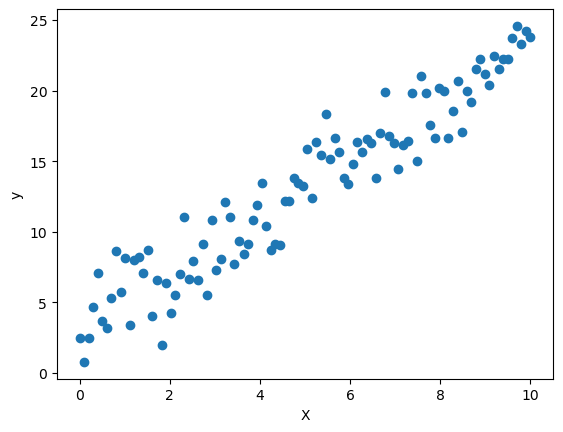

In [6]:
# Generate synthetic data for linear regression
X = torch.linspace(0, 10, 100).reshape(-1, 1)
y = 2 * X + 3 + torch.randn(100, 1) * 2  # Linear relation with some noise

# Visualize the data
plt.scatter(X.numpy(), y.numpy())
plt.xlabel("X")
plt.ylabel("y")

Defining these classes, and the structure inside the class, is what is commonly known as the "architecture" of your model.

In [7]:
class LinearRegressionModel(nn.Module):
    def __init__(self):
        super(LinearRegressionModel, self).__init__()
        self.linear = nn.Linear(1, 1)  # 1 input feature, 1 output feature

    def forward(self, x):
        return self.linear(x)

In [8]:
# Instantiate the model
model = LinearRegressionModel()

# Define the loss function (Mean Squared Error)
criterion = nn.MSELoss()

# Define the optimizer (Stochastic Gradient Descent with a learning rate of 0.01)
optimizer = optim.SGD(model.parameters(), lr=0.01)

In [9]:
# Training loop
num_epochs = 100
for epoch in range(num_epochs):
    # Forward pass: compute predictions and loss
    predictions = model(X)
    loss = criterion(predictions, y)
    
    # Backward pass: compute gradients and update parameters
    optimizer.zero_grad()  # Reset gradients to zero
    loss.backward()        # Backpropagate the error
    optimizer.step()       # Update parameters
    
    # Print progress
    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch + 1}/{num_epochs}], Loss: {loss.item():.4f}")

Epoch [10/100], Loss: 5.4686
Epoch [20/100], Loss: 5.2728
Epoch [30/100], Loss: 5.0957
Epoch [40/100], Loss: 4.9353
Epoch [50/100], Loss: 4.7900
Epoch [60/100], Loss: 4.6586
Epoch [70/100], Loss: 4.5396
Epoch [80/100], Loss: 4.4319
Epoch [90/100], Loss: 4.3344
Epoch [100/100], Loss: 4.2461


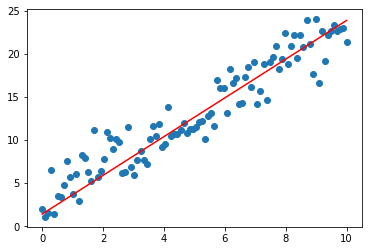

In [9]:
# Plot the model's predictions
predicted = model(X).detach().numpy()  # Detach to convert to numpy
plt.plot(X.numpy(), predicted, color="red", label="Fitted Line")
plt.scatter(X.numpy(), y.numpy())

In [10]:
model.linear.weight.data, model.linear.bias.data

(tensor([[2.2476]]), tensor([1.3743]))

### Using the template code above, generate 3-dimensional synthetic linear regression data
You are encouraged to translate your homework solution from numpy into torch.

In [10]:
# Generate synthetic data for linear regression
X1 = torch.linspace(0, 10, 100).reshape(-1, 1) + torch.randn(100, 1)
X2 = torch.linspace(0, 10, 100).reshape(-1, 1) + torch.randn(100, 1)
X3 = torch.linspace(0, 10, 100).reshape(-1, 1) + torch.randn(100, 1)
X_multi = torch.hstack((X1, X2, X3))
B  = torch.tensor([1.0, 2.0, 3.0, 4.0])
y_multi = B[0] + (X_multi * B[1:]).sum(axis=1).unsqueeze(1) + torch.randn(100, 1)

In [11]:
y_multi

tensor([[ -1.6492],
        [  4.0271],
        [  6.3207],
        [  5.9597],
        [  9.2339],
        [  5.7445],
        [  6.2789],
        [  9.0119],
        [  4.9208],
        [  7.6652],
        [ 12.3311],
        [ 19.6241],
        [ 11.2290],
        [ 13.3886],
        [ 10.7394],
        [ 11.3370],
        [ 25.3721],
        [ 22.1143],
        [ 22.7342],
        [ 21.3453],
        [ 16.6175],
        [ 15.4614],
        [ 27.5010],
        [ 19.2182],
        [ 19.3591],
        [ 27.2184],
        [  7.1471],
        [ 17.9344],
        [ 27.8909],
        [ 40.9323],
        [ 25.9128],
        [ 18.1828],
        [ 30.4689],
        [ 27.4097],
        [ 32.4372],
        [ 34.6442],
        [ 36.0444],
        [ 31.7395],
        [ 41.4771],
        [ 34.5226],
        [ 38.4225],
        [ 37.9006],
        [ 36.4097],
        [ 43.5752],
        [ 44.9719],
        [ 50.9366],
        [ 47.5214],
        [ 36.4417],
        [ 43.5366],
        [ 45.2360],


Build your own neural net!

In [12]:
class MultiLinearRegressionModel(nn.Module):
    def __init__(self):
        super(MultiLinearRegressionModel, self).__init__()
        self.linear = nn.Linear(3, 1)  # 1 input feature, 1 output feature

    def forward(self, x):
        return self.linear(x)

In [13]:
# Instantiate the model
model_1 = MultiLinearRegressionModel()

# Define the loss function (Mean Squared Error)
criterion = nn.MSELoss()

# Define the optimizer (Stochastic Gradient Descent with a learning rate of 0.01)
optimizer = optim.SGD(model_1.parameters(), lr=0.001)

In [14]:
# Training loop
num_epochs = 2000
for epoch in range(num_epochs):
    # Forward pass: compute predictions and loss
    predictions = model_1(X_multi)
    loss = criterion(predictions, y_multi)
    
    # Backward pass: compute gradients and update parameters
    optimizer.zero_grad()  # Reset gradients to zero
    loss.backward()        # Backpropagate the error
    optimizer.step()       # Update parameters
    
    # Print progress
    if (epoch + 1) % 100 == 0:
        print(f"Epoch [{epoch + 1}/{num_epochs}], Loss: {loss.item():.4f}")

Epoch [100/2000], Loss: 2.0764
Epoch [200/2000], Loss: 1.8113
Epoch [300/2000], Loss: 1.6182
Epoch [400/2000], Loss: 1.4771
Epoch [500/2000], Loss: 1.3736
Epoch [600/2000], Loss: 1.2972
Epoch [700/2000], Loss: 1.2407
Epoch [800/2000], Loss: 1.1984
Epoch [900/2000], Loss: 1.1667
Epoch [1000/2000], Loss: 1.1426
Epoch [1100/2000], Loss: 1.1241
Epoch [1200/2000], Loss: 1.1099
Epoch [1300/2000], Loss: 1.0987
Epoch [1400/2000], Loss: 1.0898
Epoch [1500/2000], Loss: 1.0827
Epoch [1600/2000], Loss: 1.0769
Epoch [1700/2000], Loss: 1.0721
Epoch [1800/2000], Loss: 1.0681
Epoch [1900/2000], Loss: 1.0648
Epoch [2000/2000], Loss: 1.0619


## Building a neural net for XOR

Build a neural net for solving the XOR problem. The first line layer is written for you.
Use the training code from above to make one run.

In [15]:
# XOR inputs and labels
X = torch.tensor([[0, 0], 
                  [0, 1], 
                  [1, 0], 
                  [1, 1]], dtype=torch.float32)

y = torch.tensor([[0], 
                  [1], 
                  [1], 
                  [0]], dtype=torch.float32)

We use **ReLU** between the layers (so the network can learn nonlinear shapes) and **sigmoid** on the output (to squash it into a 0–1 probability).

In [16]:
class XORNet(nn.Module):
    def __init__(self):
        super(XORNet, self).__init__()
        self.fc1 = nn.Linear(2, 8)   # Input layer to hidden layer
        self.fc2 = nn.Linear(8, 1)   # Hidden layer to output layer

    def forward(self, x):
        x = self.fc1(x)
        x = torch.relu(x)  # ReLU activation for hidden layer
        x = self.fc2(x)
        x = torch.sigmoid(x)  # Sigmoid activation for output layer
        return x

# Instantiate the model
model = XORNet()

In [17]:
criterion = nn.MSELoss()
optimizer = optim.SGD(model.parameters(), lr=0.1)

In [18]:
# Training loop
num_epochs = 10000
for epoch in range(num_epochs):
    # Forward pass: compute the output and loss
    y_pred = model(X)
    loss = criterion(y_pred, y)
    
    # Backward pass and optimization
    optimizer.zero_grad()   # Zero out gradients from the previous step
    loss.backward()         # Compute new gradients
    optimizer.step()        # Update parameters

    # Print the loss every 1000 epochs
    if (epoch + 1) % 1000 == 0:
        print(f"Epoch [{epoch + 1}/{num_epochs}], Loss: {loss.item():.4f}")

Epoch [1000/10000], Loss: 0.1048
Epoch [2000/10000], Loss: 0.0123
Epoch [3000/10000], Loss: 0.0050
Epoch [4000/10000], Loss: 0.0030
Epoch [5000/10000], Loss: 0.0021
Epoch [6000/10000], Loss: 0.0016
Epoch [7000/10000], Loss: 0.0012
Epoch [8000/10000], Loss: 0.0010
Epoch [9000/10000], Loss: 0.0009
Epoch [10000/10000], Loss: 0.0008


In [19]:
model_params = list(model.parameters())
model_params

[Parameter containing:
 tensor([[-0.3975,  2.2952],
         [-0.7513,  0.7512],
         [-1.8661, -1.8659],
         [-0.1378, -0.6009],
         [-0.4496, -0.1154],
         [-0.2375,  1.4882],
         [ 0.3113, -0.4222],
         [-2.4666,  2.4666]], requires_grad=True),
 Parameter containing:
 tensor([ 3.9753e-01, -1.3287e-05,  1.8659e+00, -5.6830e-01, -2.3609e-01,
          2.3747e-01, -3.1298e-01, -1.1902e-05], requires_grad=True),
 Parameter containing:
 tensor([[-2.3127,  0.9408, -3.1469, -0.2196, -0.0438, -1.0628, -0.2849,  3.4000]],
        requires_grad=True),
 Parameter containing:
 tensor([3.0712], requires_grad=True)]

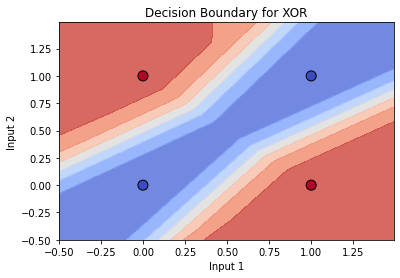

In [18]:
# Plot decision boundary
x_min, x_max = -0.5, 1.5
y_min, y_max = -0.5, 1.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01),
                     np.arange(y_min, y_max, 0.01))
grid_input = torch.tensor(np.c_[xx.ravel(), yy.ravel()], dtype=torch.float32)
with torch.no_grad():
    grid_pred = model(grid_input)
    grid_pred = grid_pred.reshape(xx.shape).numpy()
plt.contourf(xx, yy, grid_pred, alpha=0.8, cmap='coolwarm')
plt.scatter(X[:, 0], X[:, 1], c=y.squeeze().numpy(), edgecolor='k', s=100, cmap='coolwarm')
plt.title("Decision Boundary for XOR")
plt.xlabel("Input 1")
plt.ylabel("Input 2")
plt.show()